## **Implementação de MLP: Aprendendo XOR**

A função **XOR** recebe dois valores $x_1$ e $x_2$, pertencendes ao conjunto $\{0, 1\}$, e mapeia o resultado de acordo com a tabela verdade:

| $x_2$ | $x_2$ | Output |
|---|---|---|
| $1$ | $1$ | $0$ |
| $1$ | $0$ | $1$ |
| $0$ | $1$ | $1$ |
| $0$ | $0$ | $0$ |

Vamos usar *Pytorch* - my first step, omg - então vamos nos familiarizar com os métodos e funções disponíveis.

**Importando a biblioteca ``torch`` e ``torch.nn`` usada para Redes Neurais**

In [38]:
import torch
import torch.nn as nn

**Criando o dataset usando um tensor**

In [39]:
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
T = torch.tensor([[0],[1],[1],[0]],         dtype=torch.float32)

**Criando o modelo seguindo o seguinte padrão:**

In [40]:
model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

O modelo é definido como uma sequência de camadas:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(2,2)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{2\times2},\; \mathbf{b}^{(1)} \in \mathbb{R}^{2}},\;
    \sigma,\;
    \underbrace{\text{Linear}(2,1)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{1\times2},\; \mathbf{b}^{(2)} \in \mathbb{R}^{1}},\;
    \sigma
\bigr)
$$

Cada camada $\text{Linear}$ computa:

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)} + \mathbf{b}^{(\ell)}
$$

e a função de ativação é aplicada elemento a elemento:

$$
\mathbf{z}^{(\ell)} = \sigma\!\left(\mathbf{a}^{(\ell)}\right)
$$

**Loss e Otimizador**

Aqui vamos utilizar como função de perda a *Binary Cross-Entropy (BCE)* e como otimizador o *Stochastic Gradient Descent (SGD)*:

In [41]:
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

**Treino**

In [42]:
losses = []

for epoch in range(10000):
    y = model(X)
    loss = criterion(y, T)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
            print(f"Época {epoch:5d}  |  E = {loss:.6f}")

Época     0  |  E = 0.708953
Época  1000  |  E = 0.692648
Época  2000  |  E = 0.100036
Época  3000  |  E = 0.017776
Época  4000  |  E = 0.009356
Época  5000  |  E = 0.006302
Época  6000  |  E = 0.004738
Época  7000  |  E = 0.003790
Época  8000  |  E = 0.003156
Época  9000  |  E = 0.002702


**Curva de Aprendizado**

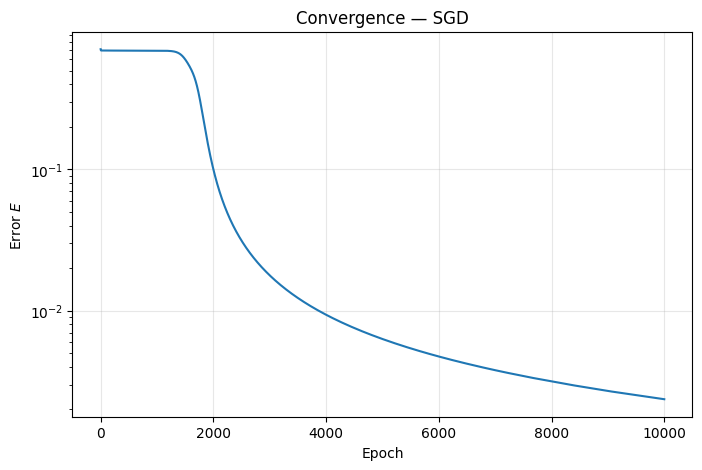

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel(r"Error $E$")
plt.title("Convergence — SGD")
plt.grid(True, alpha=0.3)
plt.yscale("log")
plt.show()

**Parâmetros do Modelo**

In [44]:
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

0.weight: tensor([[-5.9970, -5.9971],
        [-7.2861, -7.2865]])
0.bias: tensor([8.9551, 3.1208])
2.weight: tensor([[ 13.3826, -13.8165]])
2.bias: tensor([-6.3567])


**Inferência**

In [45]:
with torch.no_grad():
    print(model(X).round())

tensor([[0.],
        [1.],
        [1.],
        [0.]])
